# Eksplorasi Pertemuan 6 — Efek Kernel & CNN Keras
Terapkan berbagai kernel pada citra digit, lalu (opsional) latih CNN di Keras/Colab.

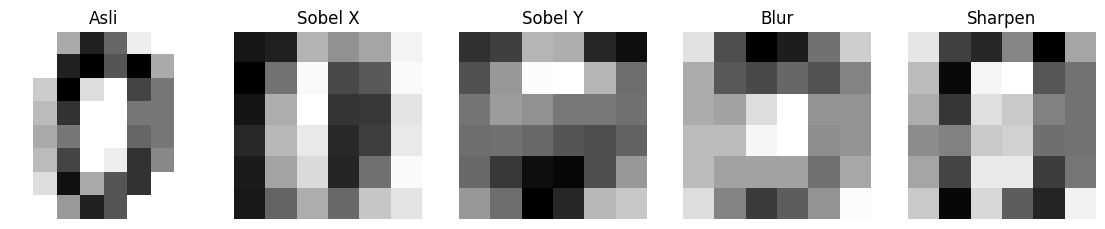

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from cnn import konvolusi2d, relu, max_pooling, SOBEL_X, SOBEL_Y, BLUR, SHARPEN

citra = load_digits().images[0]  # digit 0, 8x8
kernels = {"Asli": None, "Sobel X": SOBEL_X, "Sobel Y": SOBEL_Y, "Blur": BLUR, "Sharpen": SHARPEN}
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, (nama, k) in zip(axes, kernels.items()):
    hasil = citra if k is None else konvolusi2d(citra, k)
    ax.imshow(hasil, cmap="gray_r"); ax.set_title(nama); ax.axis("off")
plt.show()

In [2]:
# Opsional — CNN Keras untuk MNIST (jalankan di Colab jika TF tak ada)
from tensorflow import keras
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(8, 3, activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(16, 3, activation="relu"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()  # cocokkan ukuran feature map dengan hitunganmu di SUBMISSION.md!

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,258 (20.54 KB)

 Trainable params: 5,258 (20.54 KB)

 Non-trainable params: 0 (0.00 B)